In [1]:
# ============================================
# Import Libraries
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================
# Check Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================
# Data Preprocessing
# ============================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ============================================
# Load MNIST Dataset
# ============================================

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# ============================================
# DataLoader
# ============================================

batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 45.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.25MB/s]


In [2]:
# ============================================
# CNN Model
# ============================================

class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

# ============================================
# Training Function
# ============================================

def train_model(model, optimizer, epochs=5):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)

        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)

        train_accuracies.append(epoch_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {epoch_loss:.4f} "
              f"Accuracy: {epoch_accuracy:.2f}%")

    return train_losses, train_accuracies


========== Experiment 1 : Adam ==========

Epoch [1/5] Loss: 0.2503 Accuracy: 92.28%
Epoch [2/5] Loss: 0.0905 Accuracy: 97.31%
Epoch [3/5] Loss: 0.0682 Accuracy: 98.06%
Epoch [4/5] Loss: 0.0555 Accuracy: 98.37%
Epoch [5/5] Loss: 0.0478 Accuracy: 98.57%

Adam Test Accuracy: 99.18
Adam Test Loss: 0.02369784831252954

========== Experiment 2 : SGD ==========

Epoch [1/5] Loss: 0.9418 Accuracy: 72.49%
Epoch [2/5] Loss: 0.2636 Accuracy: 92.29%
Epoch [3/5] Loss: 0.1785 Accuracy: 94.77%
Epoch [4/5] Loss: 0.1410 Accuracy: 96.00%
Epoch [5/5] Loss: 0.1196 Accuracy: 96.52%

SGD Test Accuracy: 97.79
SGD Test Loss: 0.0644896275369053


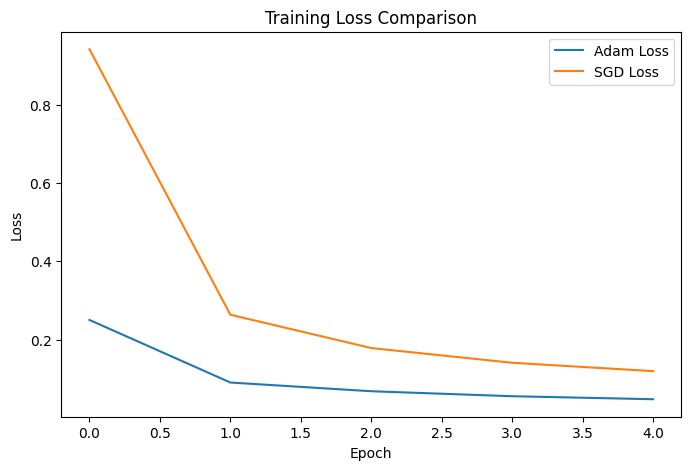

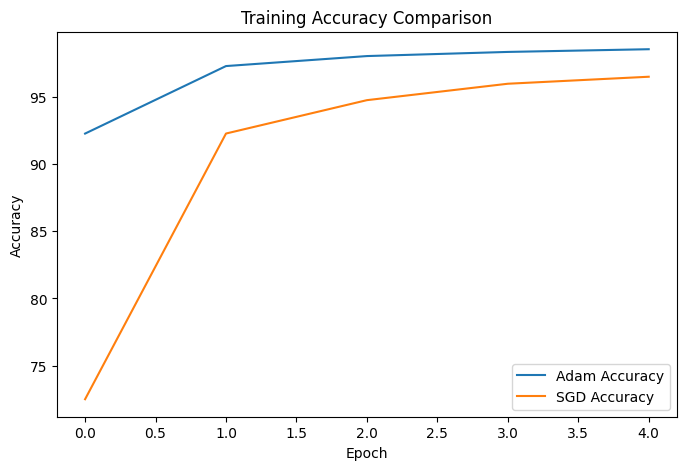


Final Comparison Results
Model                Accuracy        Loss
CNN + Adam           99.18%           0.0237
CNN + SGD            97.79%           0.0645


In [3]:
# ============================================
# Testing Function
# ============================================

def test_model(model):

    criterion = nn.CrossEntropyLoss()

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    final_loss = test_loss / len(test_loader)

    final_accuracy = 100 * correct / total

    return final_loss, final_accuracy

# ============================================
# Experiment 1
# CNN + Adam
# ============================================

print("\n========== Experiment 1 : Adam ==========\n")

model_adam = SimpleCNN().to(device)

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

adam_losses, adam_accuracies = train_model(
    model_adam,
    optimizer_adam
)

adam_test_loss, adam_test_accuracy = test_model(model_adam)

print("\nAdam Test Accuracy:", adam_test_accuracy)
print("Adam Test Loss:", adam_test_loss)

# ============================================
# Experiment 2
# CNN + SGD
# ============================================

print("\n========== Experiment 2 : SGD ==========\n")

model_sgd = SimpleCNN().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01
)

sgd_losses, sgd_accuracies = train_model(
    model_sgd,
    optimizer_sgd
)

sgd_test_loss, sgd_test_accuracy = test_model(model_sgd)

print("\nSGD Test Accuracy:", sgd_test_accuracy)
print("SGD Test Loss:", sgd_test_loss)

# ============================================
# Visualization
# Training Loss Curves
# ============================================

plt.figure(figsize=(8,5))

plt.plot(adam_losses, label='Adam Loss')

plt.plot(sgd_losses, label='SGD Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training Loss Comparison')

plt.legend()

plt.show()

# ============================================
# Visualization
# Training Accuracy Curves
# ============================================

plt.figure(figsize=(8,5))

plt.plot(adam_accuracies, label='Adam Accuracy')

plt.plot(sgd_accuracies, label='SGD Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training Accuracy Comparison')

plt.legend()

plt.show()

# ============================================
# Final Results Table
# ============================================

print("\n===================================")
print("Final Comparison Results")
print("===================================")

print(f"{'Model':<20} {'Accuracy':<15} {'Loss'}")

print(f"{'CNN + Adam':<20} "
      f"{adam_test_accuracy:.2f}%"
      f"{'':<10} "
      f"{adam_test_loss:.4f}")

print(f"{'CNN + SGD':<20} "
      f"{sgd_test_accuracy:.2f}%"
      f"{'':<10} "
      f"{sgd_test_loss:.4f}")